In [7]:
import pandas as pd
import matplotlib.pyplot as plt


In [8]:
df1 = pd.read_csv("Unemployment in India.csv")
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")


In [10]:
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()
print(df1.columns)
print(df2.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')
Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')


In [32]:
print("DATASET 1")
print(df1.head())

print("\nDATASET 2")
print(df2.head())

print("\nDATASET 1 SHAPE")
print(df1.shape)

print("\nDATASET 2 SHAPE")
print(df2.shape)

print("\nDATASET 1 COLUMNS")
print(df1.columns)

print("\nDATASET 2 COLUMNS")
print(df2.columns)

DATASET 1
           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   
3  Andhra Pradesh   31-08-2019   Monthly                             3.32   
4  Andhra Pradesh   30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  

DATASET 2
           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andh

In [33]:
df1 = df1.dropna()
df2 = df2.dropna()

print("\nMissing Values Dataset 1")
print(df1.isnull().sum())

print("\nMissing Values Dataset 2")
print(df2.isnull().sum())


Missing Values Dataset 1
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

Missing Values Dataset 2
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


In [12]:
rate_col = "Estimated Unemployment Rate (%)"

print("\nHighest Unemployment Rate")
print(df1[rate_col].max())

print("\nLowest Unemployment Rate")
print(df1[rate_col].min())

print("\nAverage Unemployment Rate")
print(df1[rate_col].mean())


Highest Unemployment Rate
76.74

Lowest Unemployment Rate
0.0

Average Unemployment Rate
11.787945945945946


In [19]:
print(pd.cut(df1[rate_col],bins=10).value_counts().sort_index())

Estimated Unemployment Rate (%)
(-0.0767, 7.674]    350
(7.674, 15.348]     196
(15.348, 23.022]     99
(23.022, 30.696]     55
(30.696, 38.37]      19
(38.37, 46.044]      10
(46.044, 53.718]      4
(53.718, 61.392]      2
(61.392, 69.066]      1
(69.066, 76.74]       4
Name: count, dtype: int64


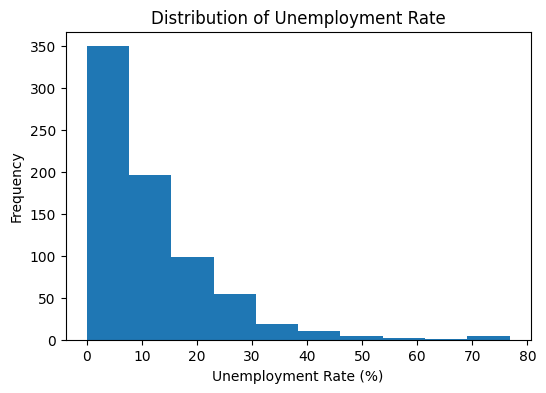

In [16]:
plt.figure(figsize=(6,4))
plt.hist(df1[rate_col])
plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")
plt.show()



Average Unemployment by Region
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


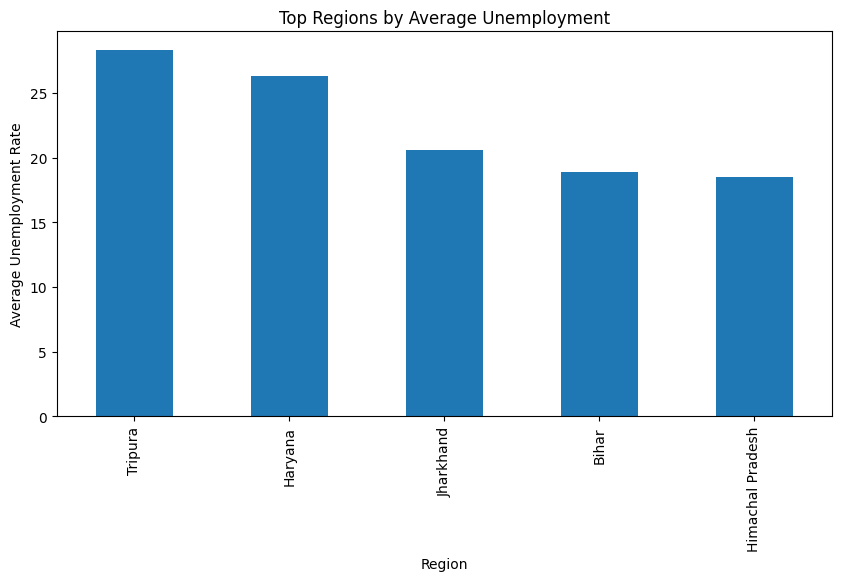

In [20]:
state_avg = df1.groupby("Region")[rate_col].mean()

print("\nAverage Unemployment by Region")
print(state_avg.sort_values(ascending=False))

plt.figure(figsize=(10,5))
state_avg.sort_values(ascending=False).head().plot(kind="bar")
plt.title("Top Regions by Average Unemployment")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate")
plt.show()

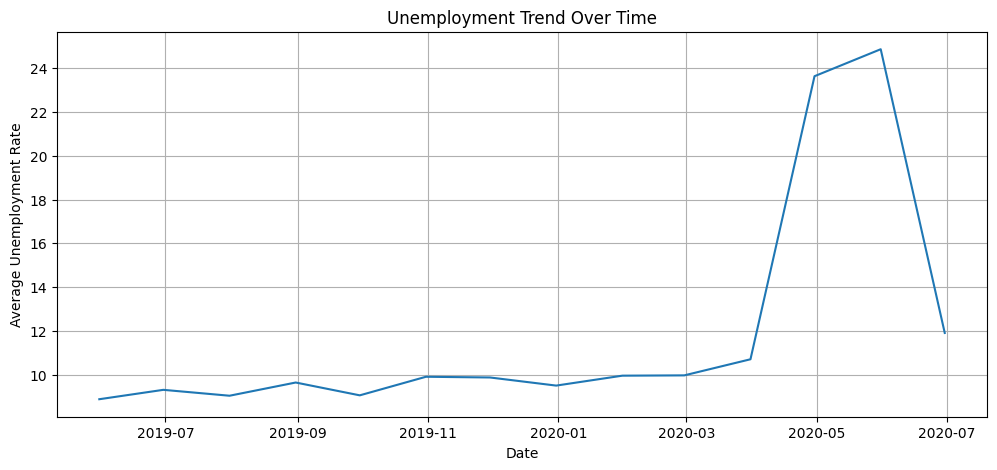

In [39]:
df1["Date"] = pd.to_datetime(df1["Date"])

trend = df1.groupby("Date")[rate_col].mean()

plt.figure(figsize=(12,5))
plt.plot(trend.index, trend.values)
plt.title("Unemployment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate")
plt.grid(True)
plt.show()


COVID ANALYSIS
Average Before COVID : 9.509533582089553
Average During COVID : 17.774362745098042


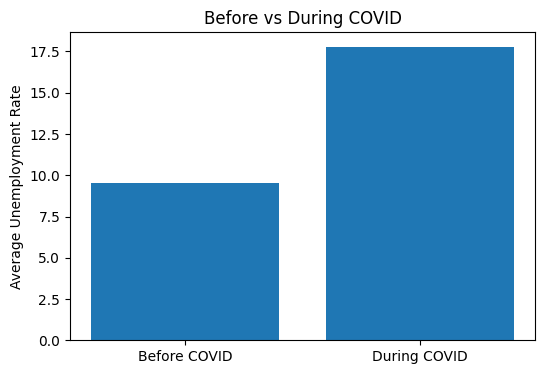

In [40]:
before_covid = df1[df1["Date"] < "2020-03-01"]
during_covid = df1[df1["Date"] >= "2020-03-01"]

before_avg = before_covid[rate_col].mean()
during_avg = during_covid[rate_col].mean()

print("\nCOVID ANALYSIS")
print("Average Before COVID :", before_avg)
print("Average During COVID :", during_avg)

plt.figure(figsize=(6,4))
plt.bar(
    ["Before COVID", "During COVID"],
    [before_avg, during_avg]
)

plt.title("Before vs During COVID")
plt.ylabel("Average Unemployment Rate")
plt.show()

In [41]:
most_affected = state_avg.idxmax()

print("\nMost Affected Region")

print(most_affected)


Most Affected Region
Tripura


In [42]:
print("\n========== PROJECT FINDINGS ==========")

print("Highest Unemployment Rate :", df1[rate_col].max())
print("Lowest Unemployment Rate  :", df1[rate_col].min())
print("Average Unemployment Rate :", df1[rate_col].mean())
print("Most Affected Region      :", most_affected)
print("Before COVID Average      :", before_avg)
print("During COVID Average      :", during_avg)


========== PROJECT FINDINGS ==========
Highest Unemployment Rate : 76.74
Lowest Unemployment Rate  : 0.0
Average Unemployment Rate : 11.787945945945946
Most Affected Region      : Tripura
Before COVID Average      : 9.509533582089553
During COVID Average      : 17.774362745098042
